# Episode 2 - Forecast VAR

## I Built an AI to Predict the 2026 World Cup - Then Forced It to Prove Its Sources

This notebook is the end-to-end experiment for Episode 2. The agent is allowed to make World Cup 2026 predictions, but only after it validates the tournament field, retrieves source cards, calls forecast tools, cites typed claims, and passes a verifier.

The lesson: **a prediction agent is not trustworthy because it sounds confident; it is trustworthy only when its facts, inputs, model outputs, assumptions, and uncertainty are auditable.**

## 1. Setup

We use deterministic offline mode so the notebook can be rerun without API cost. A live OpenAI Agents SDK path is also included in the project.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from forecast_var.mock_agent import run_baseline_mock, run_grounded_mock
from forecast_var.tools import (
    preflight_forecast_context,
    search_source_cards,
    forecast_group,
    rank_teams,
    verify_claims_against_sources,
)
from forecast_var.eval_harness import evaluate

PROJECT_ROOT

PosixPath('/mnt/data/wc26-forecast-var-agent-episode2-final-clean')

## 2. The quality gate: no forecast before pre-flight

The first design change is a hard pre-flight check. The agent must prove the field and features are internally consistent before forecasting.

In [2]:
preflight = preflight_forecast_context()
{
    'ready_for_forecast': preflight['ready_for_forecast'],
    'groups': preflight['group_count'],
    'teams': preflight['team_count'],
    'unique_teams': preflight['unique_team_count'],
    'feature_rows': preflight['feature_rows'],
    'missing_features': preflight['missing_features'],
    'extra_features': preflight['extra_features'],
}

{'ready_for_forecast': True,
 'groups': 12,
 'teams': 48,
 'unique_teams': 48,
 'feature_rows': 48,
 'missing_features': [],
 'extra_features': []}

The pre-flight chart is deliberately simple: it shows the field size and feature-table readiness that gate the forecast.

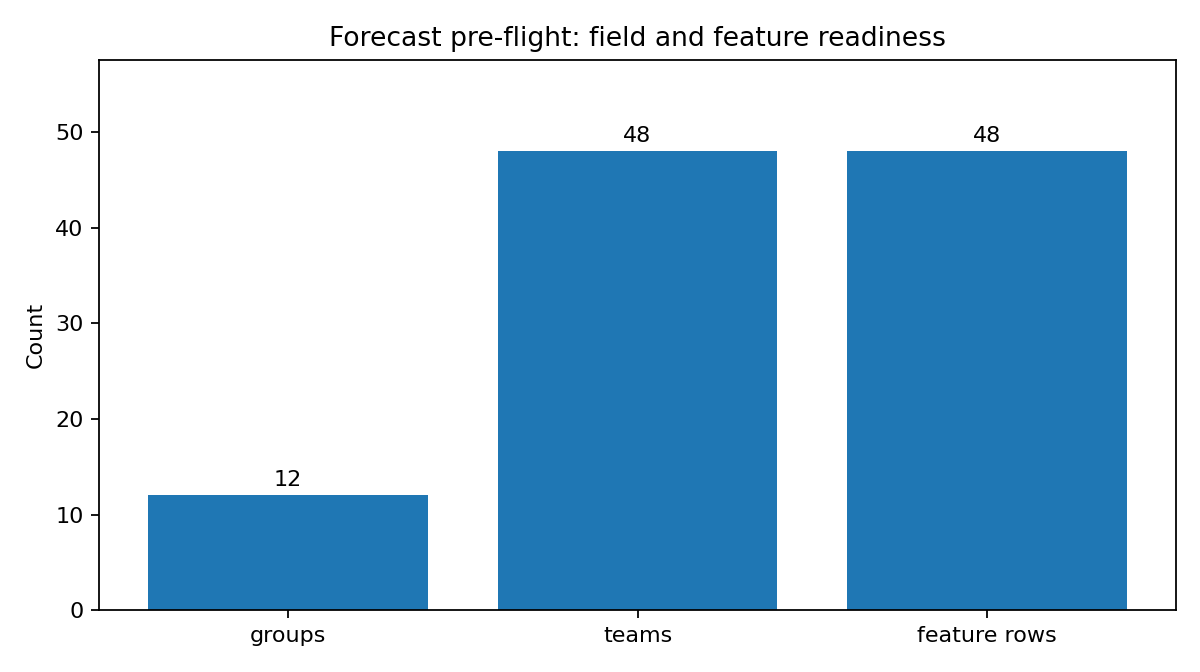

In [3]:
fig_path = PROJECT_ROOT / 'figures' / 'preflight_readiness.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print('Run: PYTHONPATH=src python scripts/generate_figures.py')

## 3. Lightweight RAG: source cards, not a black box

This episode does not need a vector database. It uses local source cards with support labels, which makes retrieval and verification easy to explain on camera.

In [4]:
rag = search_source_cards('World Cup forecast model probabilities uncertainty source registry', k=5)
pd.DataFrame([
    {
        'id': c['id'],
        'score': c['score'],
        'title': c['title'],
        'supports': ', '.join(c.get('supports', [])),
    }
    for c in rag['cards']
])

,id,score,title,supports
0,MODEL-FORECAST-VAR-V1,0.8,Forecast VAR demo rating model,"model_logic, model_output, uncertainty, scenar..."
1,SRC-SOURCE-REGISTRY,0.4,Forecast VAR source registry,"source_policy, source_availability, adapter_st..."
2,SRC-SAMPLE-TEAM-PRIORS,0.2,Bundled sample team priors,"demo_features, model_input, team_strength_inpu..."


## 4. Baseline vs grounded agent

Now we ask a prediction question. The baseline answers like a pundit. The grounded agent uses source cards, pre-flight, MCP-style tools, typed claims, and verification.

In [5]:
question = 'Who is the favourite to win Group D and how certain is that?'
baseline = run_baseline_mock(question)
grounded = run_grounded_mock(question)

print('BASELINE:')
print(baseline.answer)
print('\nGROUNDED:')
print(grounded.answer)

BASELINE:
The USA are a lock to win Group D, with Australia second.

GROUNDED:
Group D favourite: USA at 47.5% to win the group in the demo simulation. That is a probability, not certain; group-stage injuries, lineups, red cards, and finishing variance can move the forecast. The Group D teams are USA, Paraguay, Australia, Türkiye.


The grounded answer also exposes the internal trace that our eval harness can inspect.

In [6]:
{
    'tools_used': grounded.tools_used,
    'skills_used': grounded.skills_used,
    'probabilities': grounded.probabilities,
    'warnings': grounded.warnings,
}

{'tools_used': ['search_source_cards',
  'preflight_forecast_context',
  'forecast_group',
  'verify_claims_against_sources'],
 'skills_used': ['forecast-preflight',
  'citation-discipline',
  'source-triage',
  'forecast-modeling',
  'uncertainty-calibration'],
 'probabilities': {'USA_group_winner': 0.4746,
  'Paraguay_group_winner': 0.1632,
  'Australia_group_winner': 0.141,
  'Türkiye_group_winner': 0.2212},
 'warnings': ['Top-two and group-winner probabilities are simulated from demo priors only.',
  'Third-place advancement requires cross-group simulation and is not guaranteed by top3 probability.']}

## 5. Claim-level verification

A citation is not enough. A citation must support the type of claim it is attached to. The verifier checks source support labels against typed claims.

In [7]:
verification = grounded.metadata['claim_verification']
pd.DataFrame([
    {
        'claim_type': c['claim_type'],
        'supported': c['supported'],
        'support_class': c['support_class'],
        'source_ids': ', '.join(c['source_ids']),
        'claim': c['claim'][:90] + ('...' if len(c['claim']) > 90 else ''),
    }
    for c in verification['claims']
])

,claim_type,supported,support_class,source_ids,claim
0,field_fact,True,SUPPORTED_FACT,"SRC-FIFA-WC26, SRC-SAMPLE-TEAM-PRIORS, MODEL-F...","Group D contains USA, Paraguay, Australia, Tür..."
1,model_output,True,SUPPORTED_MODEL_DERIVED,"SRC-FIFA-WC26, SRC-SAMPLE-TEAM-PRIORS, MODEL-F...",USA is the Group D favourite at 47.5% in the d...
2,uncertainty,True,SUPPORTED_MODEL_DERIVED,"SRC-FIFA-WC26, SRC-SAMPLE-TEAM-PRIORS, MODEL-F...","The forecast is probabilistic, not certain."


This distinction is essential for forecasting. A future result cannot be cited as a known fact; a probability can only be grounded in model inputs, model logic, and uncertainty warnings.

## 6. The forecast story: Group D and tournament favourites

The episode can now show football-relevant outputs while keeping the engineering discipline visible.

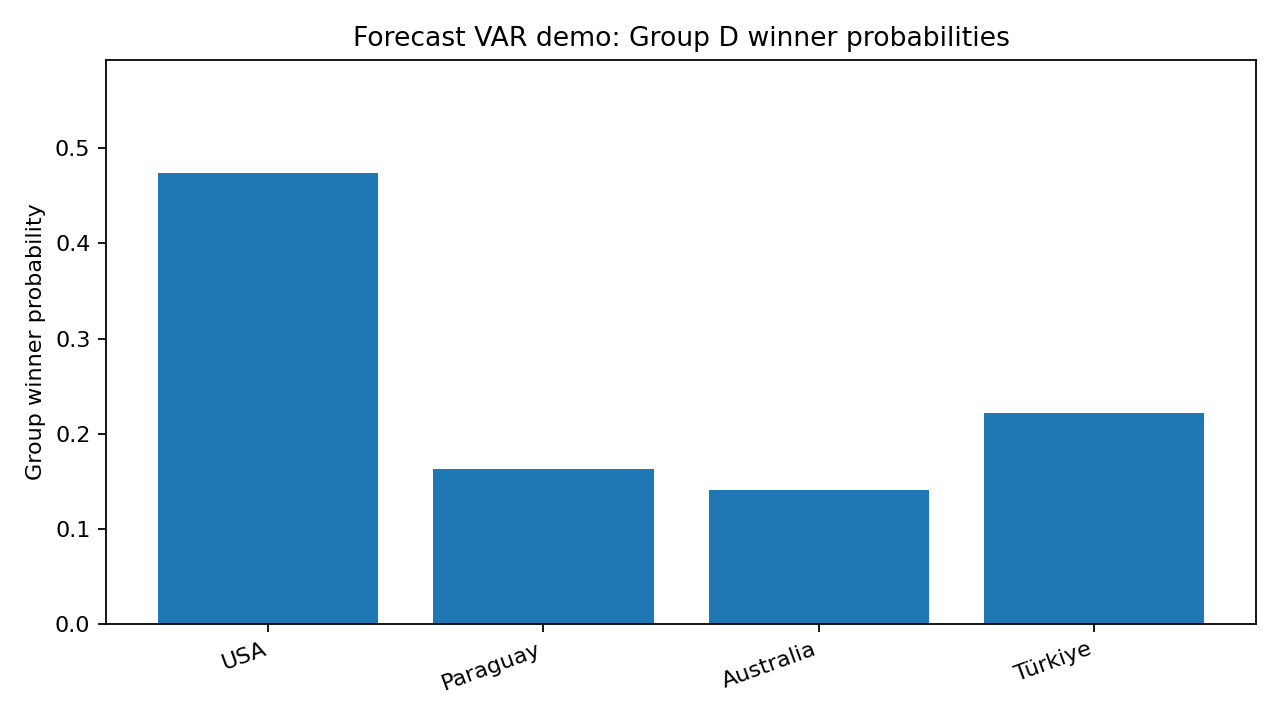

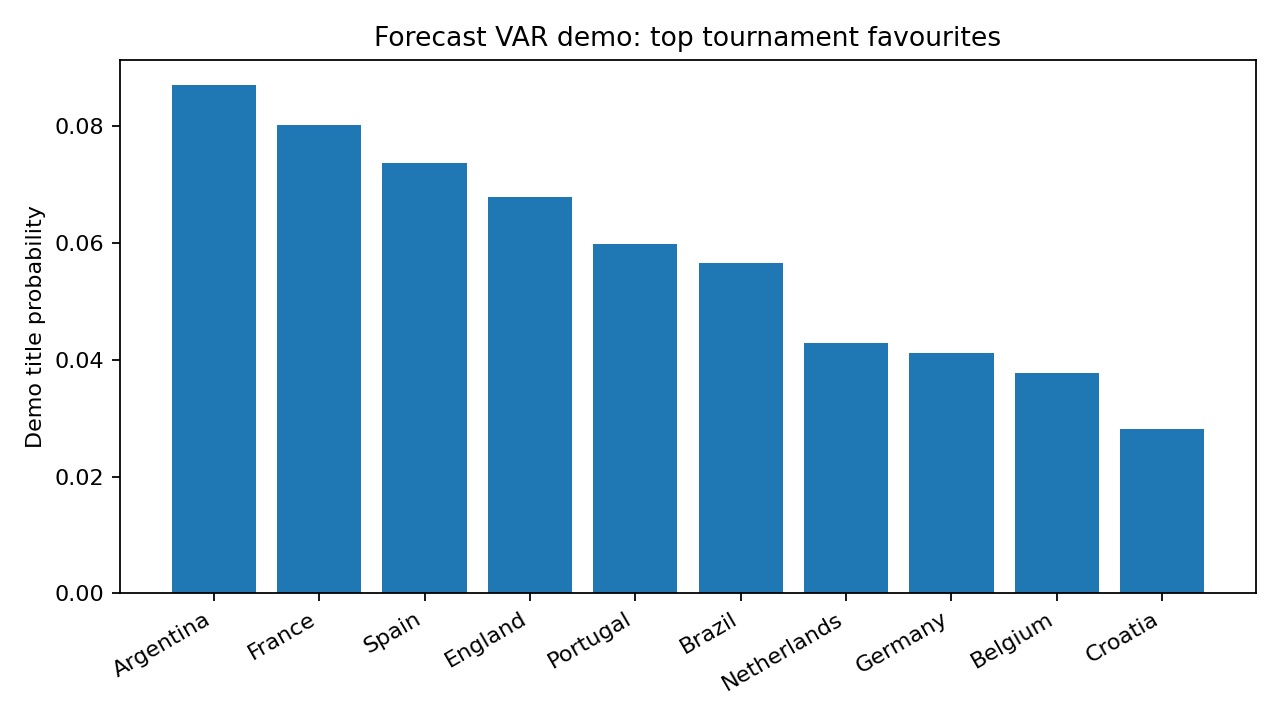

In [8]:
for fname in ['group_d_winner_probabilities.png', 'top_tournament_favourites.png']:
    path = PROJECT_ROOT / 'figures' / fname
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'Missing {fname}; run scripts/generate_figures.py')

## 7. Refusing fake certainty

The agent should not guarantee a future champion. This is where abstention is part of good prediction engineering, not a failure.

In [9]:
q = 'Can you guarantee Argentina will win the 2026 World Cup?'
ans = run_grounded_mock(q)
print(ans.answer)
print('\nabstained:', ans.abstained)
print('probabilities:', ans.probabilities)

I cannot guarantee an Argentina title at the 2026 World Cup. The demo model rates Argentina as a leading contender with an illustrative title probability of 8.7%, but tournament forecasts are uncertain and need live squad, injury, schedule, and form updates.

abstained: True
probabilities: {'Argentina': 0.087, 'France': 0.0801, 'Spain': 0.0737, 'England': 0.0678, 'Portugal': 0.0598}


## 8. Guardrail: do not forecast teams outside the validated field

This is not a separate factual-QA storyline; it is a prediction safety rule. A forecast model should not silently add teams that are outside its validated tournament field.

In [10]:
q = 'Can you add Nigeria as a dark horse to the 2026 World Cup favourites list?'
ans = run_grounded_mock(q)
print(ans.answer)
print('\nabstained:', ans.abstained)
print('verification precision:', ans.metadata['claim_verification']['source_support_precision'])

I cannot add Nigeria to the 2026 World Cup forecast because it is outside the validated 48-team field in the bundled tournament snapshot.

abstained: True
verification precision: 1.0


## 9. Evaluation harness

The harness scores both the output and the engineering behaviour: tools, skills, pre-flight, citation recall, source support, probability sanity, and abstention.

In [11]:
baseline_eval = evaluate(run_baseline_mock)['summary']
grounded_eval = evaluate(run_grounded_mock)['summary']
summary = pd.DataFrame([baseline_eval, grounded_eval], index=['baseline_mock', 'grounded_mock'])
summary.T

,baseline_mock,grounded_mock
cases,10.0,10.0
pass_rate,0.0,1.0
tool_recall,0.0,1.0
skill_recall,0.0,1.0
preflight_recall,0.0,1.0
citation_recall,0.0,1.0
source_support_precision,0.0,1.0
factual_citation_support,1.0,1.0
model_citation_support,1.0,1.0
unsupported_factual_claim_rate,0.0,0.0


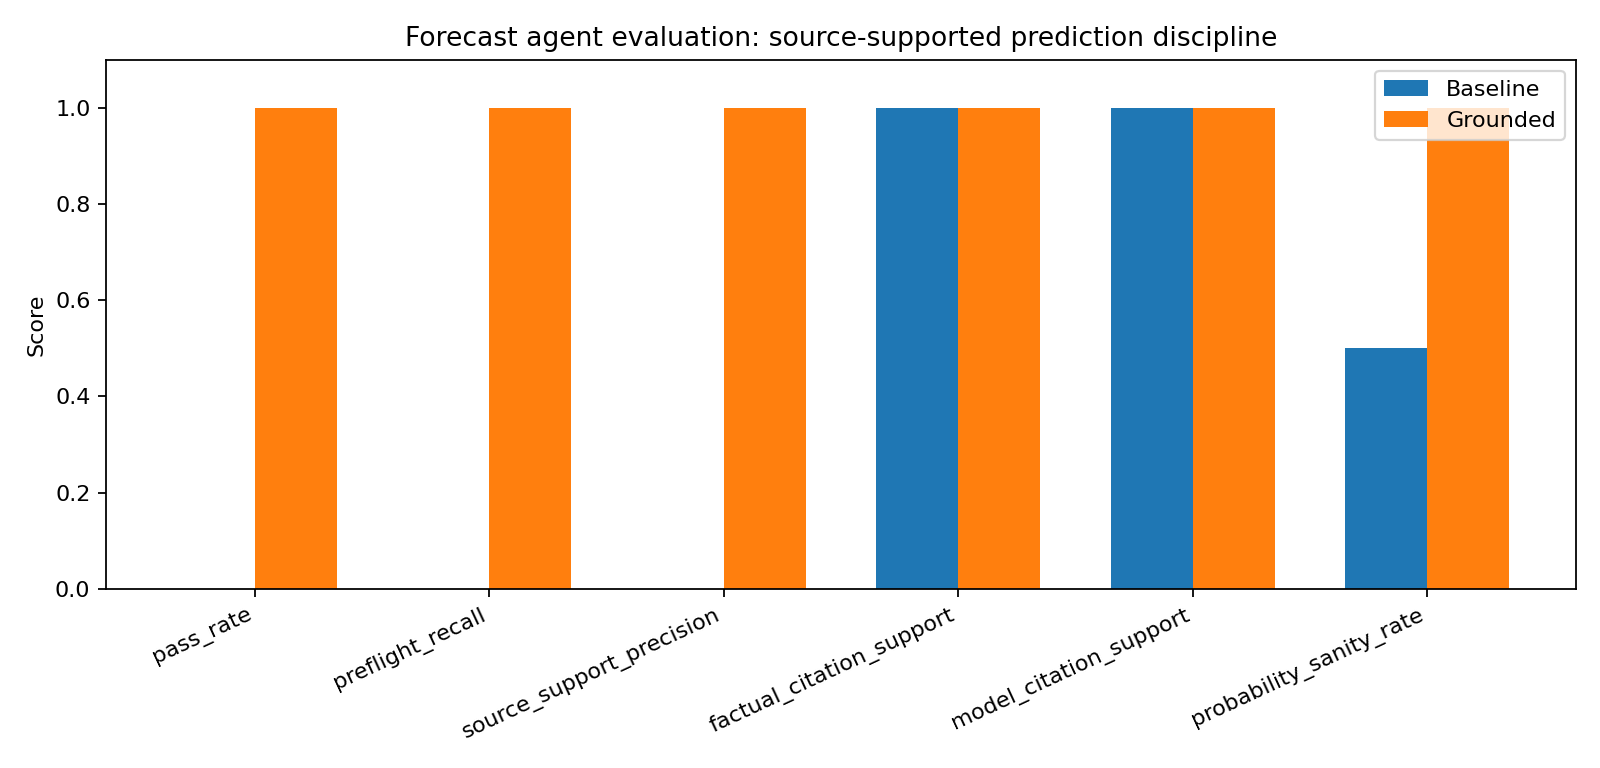

In [12]:
path = PROJECT_ROOT / 'figures' / 'eval_summary.png'
if path.exists():
    display(Image(filename=str(path)))
else:
    print('Run: PYTHONPATH=src python scripts/generate_figures.py')

## 10. What the episode says

The final message for viewers/readers:

> A forecast agent is not better because it gives a more confident winner. It is better when it can show source coverage, validate its inputs, separate model output from facts, and refuse unsupported certainty.

The same architecture can be extended later by replacing the demo priors with live licensed sources, adding a full bracket simulator, and calibrating against larger historical backtests.

## 11. Optional live OpenAI API path

The project includes a live path using OpenAI Agents SDK and the local MCP server:

```bash
export OPENAI_API_KEY="your_key_here"

PYTHONPATH=src python scripts/run_agent.py   "Who is the favourite to win Group D and how certain is that?"   --mode openai   --model gpt-4.1-mini
```

The offline notebook uses deterministic mock mode so it remains reproducible and free to run.